# exp-gs-002-10 — 08 최종 LR + B count 고정 binning

## 목적

08 최종 Logistic Regression 전처리를 고정하고, B 행별 count의 고정 구간 one-hot 12개만 추가한다. `log1p(count)`가 놓칠 수 있는 낮은 이산 count와 고부담 구간의 임계효과가 있는지 3-seed OOF로 확인한다.

## 고정 구성

- H-AS + exact hotspot 4개 + 혼동쌍 contrast + A_pair-only + B/V/A log1p
- Logistic Regression: `lbfgs`, `C=0.07`, `max_iter=2000`, `class_weight='balanced'`
- Stratified 5-fold, seeds `42/2024/777`
- fold-train only, `leakage_check=True`, `nan_as_mutation_count=0`
- OOF 실행기는 train만 읽으며 평가 데이터 파일을 읽지 않는다.

## 추가 B bin 12개

- mutated gene 수 / 전체 event 수: `1`, `2`, `3–4`, `5–7`, `8+` (`0`은 절편 기준 상태)
- multi-event gene 수: `1`, `2+` (`0`은 절편 기준 상태)

결과 후에는 bin 경계, 피처, 파라미터를 변경하지 않는다. 3개 seed 모두 양수 delta일 때만 채택 후보로 검토한다.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

def find_eda_dir() -> Path:
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / 'common' / 'exp-gs-002-memory-safe.py').exists():
            return path
        candidate = path / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002'
        if (candidate / 'common' / 'exp-gs-002-memory-safe.py').exists():
            return candidate
    raise FileNotFoundError('eda_pre_002/common 실행기를 찾지 못했습니다.')

EDA_DIR = find_eda_dir()
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = 'exp-gs-002-10'
MODEL = 'logistic'
SEEDS = (42, 2024, 777)
BASELINE = 'H-AS-LR-exact-confusion-pairs-Apair-log1p'
BINNING = 'H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins'
RUN_EXPERIMENT = True

# OOF 실행은 공통 실행기의 train-only 경로를 사용한다.
OOF_TRAIN_ONLY = True
print({'runner': RUNNER, 'result_dir': RESULT_DIR, 'seeds': SEEDS, 'oof_train_only': OOF_TRAIN_ONLY})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result'), 'seeds': (42, 2024, 777), 'oof_train_only': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 3-seed OOF 실행

baseline과 B-binning을 같은 seed에서 각각 실행한다. tqdm 진행률은 총 6회 실행 상태를 표시한다.


In [2]:
if RUN_EXPERIMENT:
    jobs = [(candidate, seed) for candidate in (BASELINE, BINNING) for seed in SEEDS]
    for candidate, seed in tqdm(jobs, desc='10 | B count binning | OOF', unit='run'):
        command = [
            sys.executable, str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', candidate,
            '--model', MODEL,
            '--seed', str(seed),
        ]
        subprocess.run(command, check=True)
else:
    print('RUN_EXPERIMENT=False: 기존 결과 파일만 집계합니다.')


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 398.00it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 42: 100%|██████████| 5/5 [03:19<00:00, 39.93s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 42,
  "oof_macro_f1": 0.47814168846488037,
  "oof_accuracy": 0.45879696823093047,
  "fold_macro_f1_mean": 0.47829869725520846,
  "fold_macro_f1_std": 0.008298637176475701,
  "feature_count_mean": 8175.2,
  "runtime_seconds": 199.74057520899805,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.11it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 2024: 100%|██████████| 5/5 [03:17<00:00, 39.54s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4762175133106753,
  "oof_accuracy": 0.4594420254797613,
  "fold_macro_f1_mean": 0.47455525475426424,
  "fold_macro_f1_std": 0.016029343519538886,
  "feature_count_mean": 8175.0,
  "runtime_seconds": 197.80846374999965,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 398.07it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | logistic | seed 777: 100%|██████████| 5/5 [03:10<00:00, 38.07s/it]


...

row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 408.23it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins | logistic | seed 2024: 100%|██████████| 5/5 [03:09<00:00, 37.82s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins",
  "model": "logistic",
  "seed": 2024,
  "oof_macro_f1": 0.4805974281981337,
  "oof_accuracy": 0.4594420254797613,
  "fold_macro_f1_mean": 0.47875298584416404,
  "fold_macro_f1_std": 0.015758689249569857,
  "feature_count_mean": 8187.0,
  "runtime_seconds": 189.19270487500762,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 406.54it/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins | logistic | seed 777: 100%|██████████| 5/5 [03:08<00:00, 37.80s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins",
  "model": "logistic",
  "seed": 777,
  "oof_macro_f1": 0.4808289060885658,
  "oof_accuracy": 0.46057087566521526,
  "fold_macro_f1_mean": 0.4798049283732942,
  "fold_macro_f1_std": 0.017036917456228932,
  "feature_count_mean": 8182.4,
  "runtime_seconds": 189.0830061250017,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


10 | B count binning | OOF: 100%|██████████| 6/6 [21:36<00:00, 216.12s/run]


## 2. paired delta·감사 조건·클래스별 F1 집계

같은 seed 내 baseline 대비 delta를 계산한다. 누수/NaN 감사 결과와 수렴 경고를 함께 확인한다.


In [3]:
def result_path(candidate: str, seed: int, suffix: str) -> Path:
    return RESULT_DIR / f'{RUN_ID}_{candidate}_{MODEL}_seed{seed}_{suffix}.csv'

summary_paths = [result_path(candidate, seed, 'oof') for candidate in (BASELINE, BINNING) for seed in SEEDS]
missing = [path for path in summary_paths if not path.exists()]
if missing:
    raise FileNotFoundError('아직 실행되지 않은 결과 파일이 있습니다:\n' + '\n'.join(map(str, missing)))

per_seed = pd.concat([pd.read_csv(path) for path in summary_paths], ignore_index=True)
assert set(per_seed['seed']) == set(SEEDS)
assert set(per_seed['experiment_id']) == {BASELINE, BINNING}
assert per_seed['leakage_check'].all()
assert per_seed['nan_as_mutation_count'].eq(0).all()

wide = per_seed.pivot(index='seed', columns='experiment_id', values='oof_macro_f1')
wide['paired_delta_binning_vs_baseline'] = wide[BINNING] - wide[BASELINE]
wide = wide.reset_index().sort_values('seed')

aggregate = (per_seed.groupby('experiment_id', as_index=False)
    .agg(seed_count=('seed', 'count'), oof_macro_f1_mean=('oof_macro_f1', 'mean'), oof_macro_f1_std=('oof_macro_f1', 'std'),
         oof_accuracy_mean=('oof_accuracy', 'mean'), feature_count_mean=('feature_count_mean', 'mean'),
         runtime_seconds_mean=('runtime_seconds', 'mean'), convergence_warning_count=('convergence_warning_count', 'sum'))
)
baseline_mean = float(aggregate.loc[aggregate['experiment_id'].eq(BASELINE), 'oof_macro_f1_mean'].iloc[0])
aggregate['delta_vs_baseline_mean'] = aggregate['oof_macro_f1_mean'] - baseline_mean
all_positive = bool(wide['paired_delta_binning_vs_baseline'].gt(0).all())
status = '채택 후보' if all_positive else '미검출/기각'

class_paths = [result_path(candidate, seed, 'class_f1') for candidate in (BASELINE, BINNING) for seed in SEEDS]
class_seed = pd.concat([pd.read_csv(path).assign(seed=seed, experiment_id=candidate) for candidate in (BASELINE, BINNING) for seed, path in ((seed, result_path(candidate, seed, 'class_f1')) for seed in SEEDS)], ignore_index=True)
class_summary = (class_seed.groupby(['experiment_id', 'class'], as_index=False)
    .agg(class_f1_mean=('f1-score', 'mean'), class_f1_std=('f1-score', 'std'), support=('support', 'first'))
)

aggregate.to_csv(RESULT_DIR / 'exp-gs-002-10_seed_summary.csv', index=False)
wide.to_csv(RESULT_DIR / 'exp-gs-002-10_paired_delta.csv', index=False)
class_summary.to_csv(RESULT_DIR / 'exp-gs-002-10_class_f1_summary.csv', index=False)
audit = {'experiment_id': RUN_ID, 'oof_train_only': OOF_TRAIN_ONLY, 'seeds': SEEDS, 'baseline': BASELINE, 'binning': BINNING, 'bin_feature_count': 12, 'all_seed_delta_positive': all_positive, 'status': status}
with (RESULT_DIR / 'exp-gs-002-10_audit.json').open('w', encoding='utf-8') as file:
    json.dump(audit, file, ensure_ascii=False, indent=2)

display(per_seed.sort_values(['experiment_id', 'seed']))
display(wide)
display(aggregate)
print(audit)


,experiment_id,model,seed,oof_macro_f1,oof_accuracy,fold_macro_f1_mean,fold_macro_f1_std,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,42,0.478142,0.458797,0.478299,0.008299,8175.2,199.740575,0,True,0
2,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,777,0.481146,0.461377,0.480232,0.016619,8170.4,190.420207,0,True,0
1,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,2024,0.476218,0.459442,0.474555,0.016029,8175.0,197.808464,0,True,0
3,H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins,logistic,42,0.479373,0.458152,0.479279,0.007713,8187.2,192.997629,0,True,0
5,H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins,logistic,777,0.480829,0.460571,0.479805,0.017037,8182.4,189.083006,0,True,0
4,H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins,logistic,2024,0.480597,0.459442,0.478753,0.015759,8187.0,189.192705,0,True,0


experiment_id,seed,H-AS-LR-exact-confusion-pairs-Apair-log1p,H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins,paired_delta_binning_vs_baseline
0,42,0.478142,0.479373,0.001231
1,777,0.481146,0.480829,-0.000317
2,2024,0.476218,0.480597,0.004380


,experiment_id,seed_count,oof_macro_f1_mean,oof_macro_f1_std,oof_accuracy_mean,feature_count_mean,runtime_seconds_mean,convergence_warning_count,delta_vs_baseline_mean
0,H-AS-LR-exact-confusion-pairs-Apair-log1p,3,0.478502,0.002484,0.459872,8173.533333,195.989749,0,0.000000
1,H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins,3,0.480266,0.000783,0.459388,8185.533333,190.424447,0,0.001765


{'experiment_id': 'exp-gs-002-10', 'oof_train_only': True, 'seeds': (42, 2024, 777), 'baseline': 'H-AS-LR-exact-confusion-pairs-Apair-log1p', 'binning': 'H-AS-LR-exact-confusion-pairs-Apair-log1p-Bbins', 'bin_feature_count': 12, 'all_seed_delta_positive': False, 'status': '미검출/기각'}


## 3. 시각화

좌측은 seed별 baseline과 binning OOF Macro F1, 우측은 paired delta다.


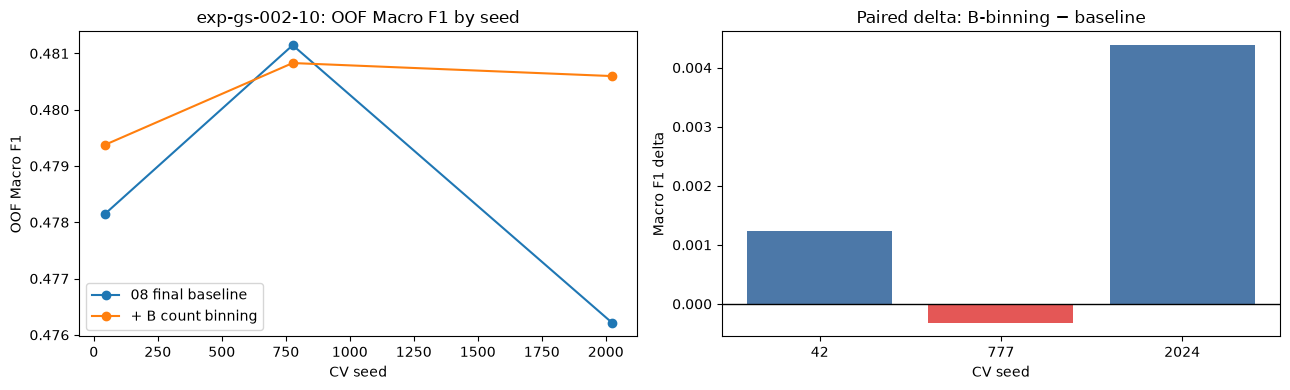

/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-10_oof_macro_f1.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for candidate, label in ((BASELINE, '08 final baseline'), (BINNING, '+ B count binning')):
    axes[0].plot(wide['seed'], wide[candidate], marker='o', label=label)
axes[0].set_title('exp-gs-002-10: OOF Macro F1 by seed')
axes[0].set_xlabel('CV seed')
axes[0].set_ylabel('OOF Macro F1')
axes[0].legend()
axes[1].axhline(0, color='black', linewidth=1)
axes[1].bar(wide['seed'].astype(str), wide['paired_delta_binning_vs_baseline'], color=['#4C78A8' if value > 0 else '#E45756' for value in wide['paired_delta_binning_vs_baseline']])
axes[1].set_title('Paired delta: B-binning − baseline')
axes[1].set_xlabel('CV seed')
axes[1].set_ylabel('Macro F1 delta')
fig.tight_layout()
plot_path = RESULT_DIR / 'exp-gs-002-10_oof_macro_f1.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
print(plot_path)
